# Fund-flow data feature tests

## tl;dr

- The source contains 2,840,421 rows, 28,041 users, and 427 complete calendar days.
- Weekly calendar structure is visible, but 427 days cannot establish stable annual seasonality.
- The 2014-08 holdout is easier than the median of the included 2014 rolling windows, so it should not be the only model-selection window.
- The random 4,000-user split is an identity-holdout stress test; the 1,457 users first observed during 2014-08-02..31 are the closer cold-start cohort.
- Linear, quadratic, and cubic score proxies all reach zero at relative error >= 0.30; the latter two penalize non-zero error more strongly.

## Context & Methods

The notebook is a reader-facing companion to `scripts/run_feature_tests.py`. It reads the immutable official balance table, rebuilds deterministic outputs, and then displays bounded evidence tables and figures.

### Key Assumptions

- `first observed` is a proxy for cold start, not confirmed signup time.
- The random user folds are relevant only to models that consume user-level identity or history.
- The official intermediate error-to-score function and zero-target convention are unknown; local scores are sensitivity proxies.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

output_dir = Path.cwd()
project_root = output_dir.parents[2]
generator = project_root / 'scripts' / 'run_feature_tests.py'
print({'python': sys.executable, 'project_root': str(project_root), 'output_dir': str(output_dir)})

{'python': 'C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast\\.venv\\Scripts\\python.exe', 'project_root': 'C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast', 'output_dir': 'C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast\\data\\derived\\d001_feature_tests'}


## Data

### 1. Rebuild deterministic outputs

In [2]:
subprocess.run(
    [
        sys.executable, str(generator),
        '--output', str(output_dir),
        '--seed', '20260824',
        '--sample-size', '4000',
        '--folds', '2',
        '--overwrite',
    ],
    cwd=project_root,
    check=True,
)

CompletedProcess(args=['C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast\\.venv\\Scripts\\python.exe', 'C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast\\scripts\\run_feature_tests.py', '--output', 'C:\\Users\\unt\\Documents\\数据\\ant-fund-flow-forecast\\data\\derived\\d001_feature_tests', '--seed', '20260824', '--sample-size', '4000', '--folds', '2', '--overwrite'], returncode=0)

### 2. Validate source shape and random folds

In [3]:
quality = pd.read_csv(output_dir / 'data_quality_summary.csv')
fold_summary = pd.read_csv(output_dir / 'cold_start_fold_summary.csv')
display(quality)
display(fold_summary)

,check,value,unit
0,rows,2840421,count
1,columns_loaded,4,count
2,unique_users,28041,count
3,date_min,2013-07-01,date
4,date_max,2014-08-31,date
5,distinct_dates,427,count
6,expected_calendar_dates,427,count
7,duplicate_user_date_rows,0,count
8,null_user_id,0,count
9,null_report_date,0,count


,fold,sampled_users,active_users,user_days,purchase_amount,redeem_amount,purchase_share_of_holdout,redeem_share_of_holdout,id_list_sha256
0,1,2000,997,28098,621405648,598740518,0.082344,0.079640,1d2a118479bf7d5fd316df54b1aac3b89b1639ef2a13bd...
1,2,2000,973,26988,637987188,711557443,0.084541,0.094646,afec50617944f5eda6ef2e30e82950792e12288745ff7f...


## Results

### 3. Inspect weekly structure

,target,weekday,mean_index,weekday_r2_log
0,total_purchase_amt,Mon,1.200446,0.053969
1,total_purchase_amt,Tue,1.215555,0.053969
2,total_purchase_amt,Wed,1.172115,0.053969
3,total_purchase_amt,Thu,1.090318,0.053969
4,total_purchase_amt,Fri,0.919605,0.053969
5,total_purchase_amt,Sat,0.682934,0.053969
6,total_purchase_amt,Sun,0.719027,0.053969
7,total_redeem_amt,Mon,1.276942,0.028718
8,total_redeem_amt,Tue,1.126064,0.028718
9,total_redeem_amt,Wed,1.142918,0.028718


,target,lag_days,raw_log_autocorrelation,detrended_log_autocorrelation
6,total_purchase_amt,7,0.816112,0.079664
13,total_purchase_amt,14,0.842025,0.325697
27,total_purchase_amt,28,0.784666,0.278777
29,total_purchase_amt,30,0.690343,-0.111543
66,total_redeem_amt,7,0.865403,0.079031
73,total_redeem_amt,14,0.865582,0.240895
87,total_redeem_amt,28,0.843573,0.252454
89,total_redeem_amt,30,0.787796,-0.048688


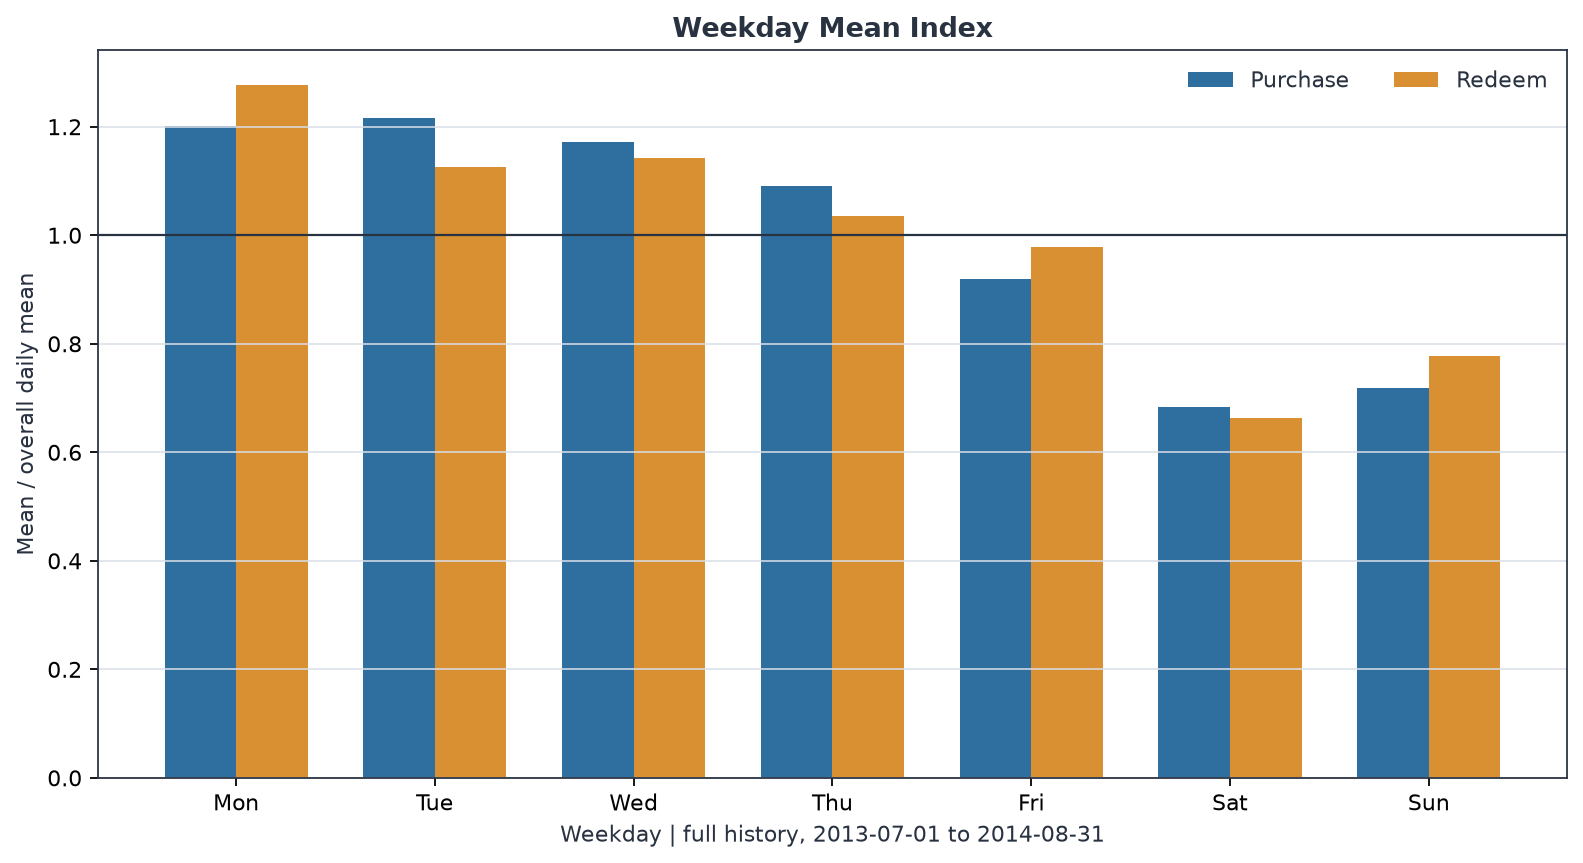

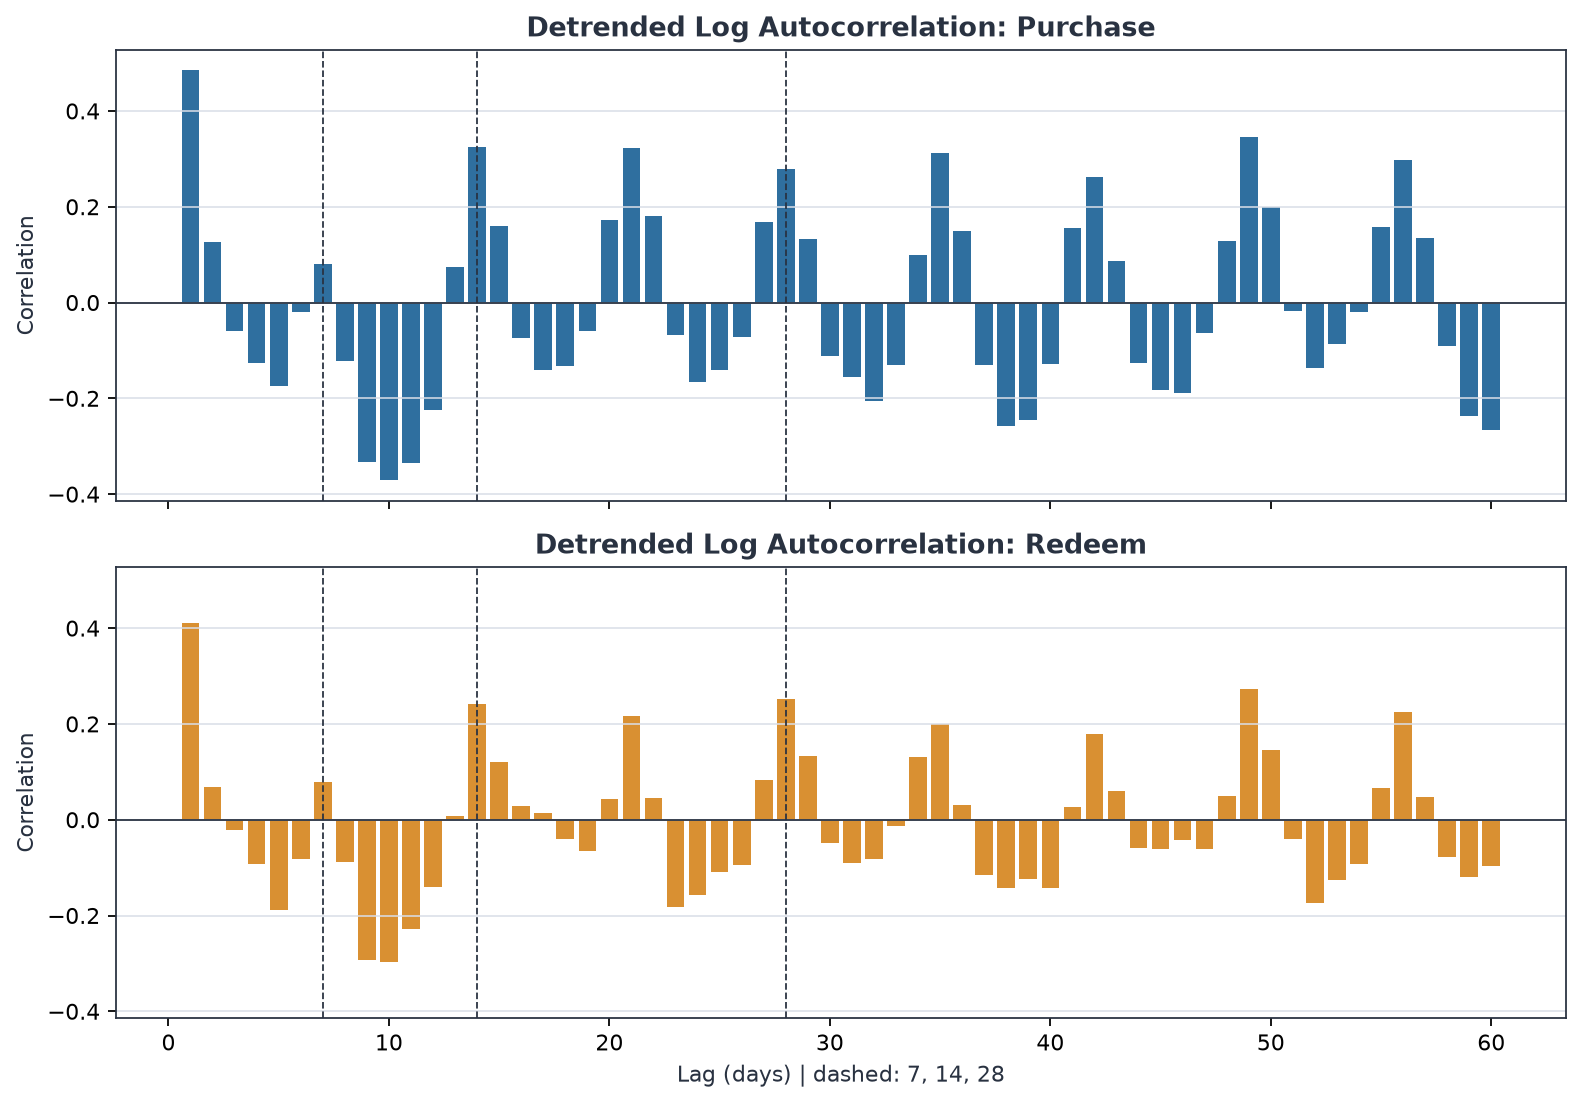

In [4]:
weekday = pd.read_csv(output_dir / 'weekday_effects.csv')
autocorrelation = pd.read_csv(output_dir / 'autocorrelation.csv')
display(weekday[['target', 'weekday', 'mean_index', 'weekday_r2_log']])
display(autocorrelation[autocorrelation['lag_days'].isin([7, 14, 28, 30])])
display(Image(filename=str(output_dir / 'weekday_pattern.png'), width=900))
display(Image(filename=str(output_dir / 'periodicity_autocorrelation.png'), width=900))

### 4. Compare requested and rolling backtests

In [5]:
metrics = pd.read_csv(output_dir / 'backtest_metrics.csv')
metric_view = metrics.pivot(
    index='window', columns='method', values='weighted_mean_relative_error'
).round(3)
display(metric_view)
display(metrics.sort_values(['window', 'proxy_score_linear'], ascending=[True, False]).groupby('window').head(1))

method,mean_last_30d,seasonal_naive_7d_recursive,weekday_mean_last_8w,weekday_median_last_8w
window,,,,
backtest_2013_09,0.404,0.441,0.449,0.451
holdout_2014_08,0.256,0.261,0.202,0.193
rolling_2014_03,0.377,0.410,0.304,0.306
rolling_2014_04,0.423,0.347,0.354,0.337
rolling_2014_05,0.283,0.194,0.238,0.222
rolling_2014_06,0.311,0.241,0.243,0.228
rolling_2014_07,0.287,0.361,0.185,0.169


,window,method,purchase_mean_relative_error,redeem_mean_relative_error,weighted_mean_relative_error,purchase_days_error_ge_0_3,redeem_days_error_ge_0_3,proxy_score_linear,proxy_score_quadratic,proxy_score_cubic
2,backtest_2013_09,weekday_median_last_8w,0.335414,0.544769,0.450559,18,24,1.618915,1.172375,0.935479
25,holdout_2014_08,weekday_mean_last_8w,0.124030,0.264940,0.201531,2,11,4.574485,3.303827,2.569224
5,rolling_2014_03,weekday_mean_last_8w,0.310149,0.299583,0.304338,13,17,2.617279,1.876593,1.505037
8,rolling_2014_04,mean_last_30d,0.381278,0.457767,0.423347,12,13,3.135390,2.061932,1.490822
15,rolling_2014_05,seasonal_naive_7d_recursive,0.187473,0.198595,0.193590,5,4,4.859186,3.339446,2.515320
19,rolling_2014_06,seasonal_naive_7d_recursive,0.168264,0.300054,0.240748,3,14,4.108275,2.861210,2.177331
22,rolling_2014_07,weekday_median_last_8w,0.191921,0.150772,0.169289,4,5,4.764807,3.257162,2.454750


### 5. Review cold-start cohorts and score sensitivity

,first_seen_month,new_users
0,2013-07,1600
1,2013-08,863
2,2013-09,778
3,2013-10,1701
4,2013-11,2590
5,2013-12,2028
6,2014-01,3312
7,2014-02,4464
8,2014-03,2561
9,2014-04,2081


,relative_error,linear_score,quadratic_score,cubic_score
0,0.00,10.000000,10.000000,10.000000
10,0.05,8.333333,6.944444,5.787037
20,0.10,6.666667,4.444444,2.962963
30,0.15,5.000000,2.500000,1.250000
40,0.20,3.333333,1.111111,0.370370
50,0.25,1.666667,0.277778,0.046296
60,0.30,0.000000,0.000000,0.000000


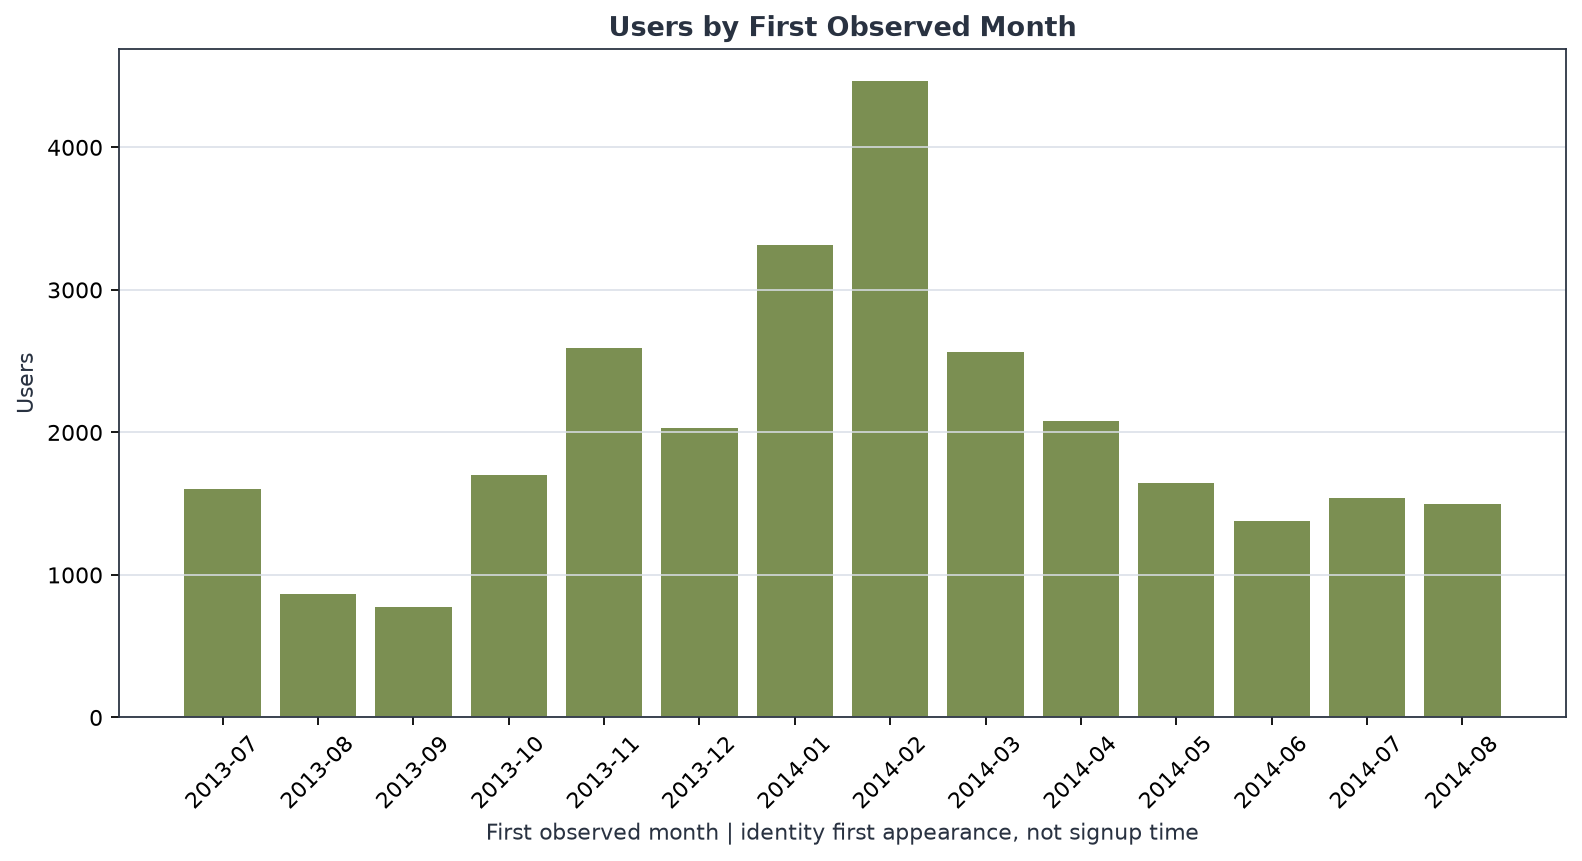

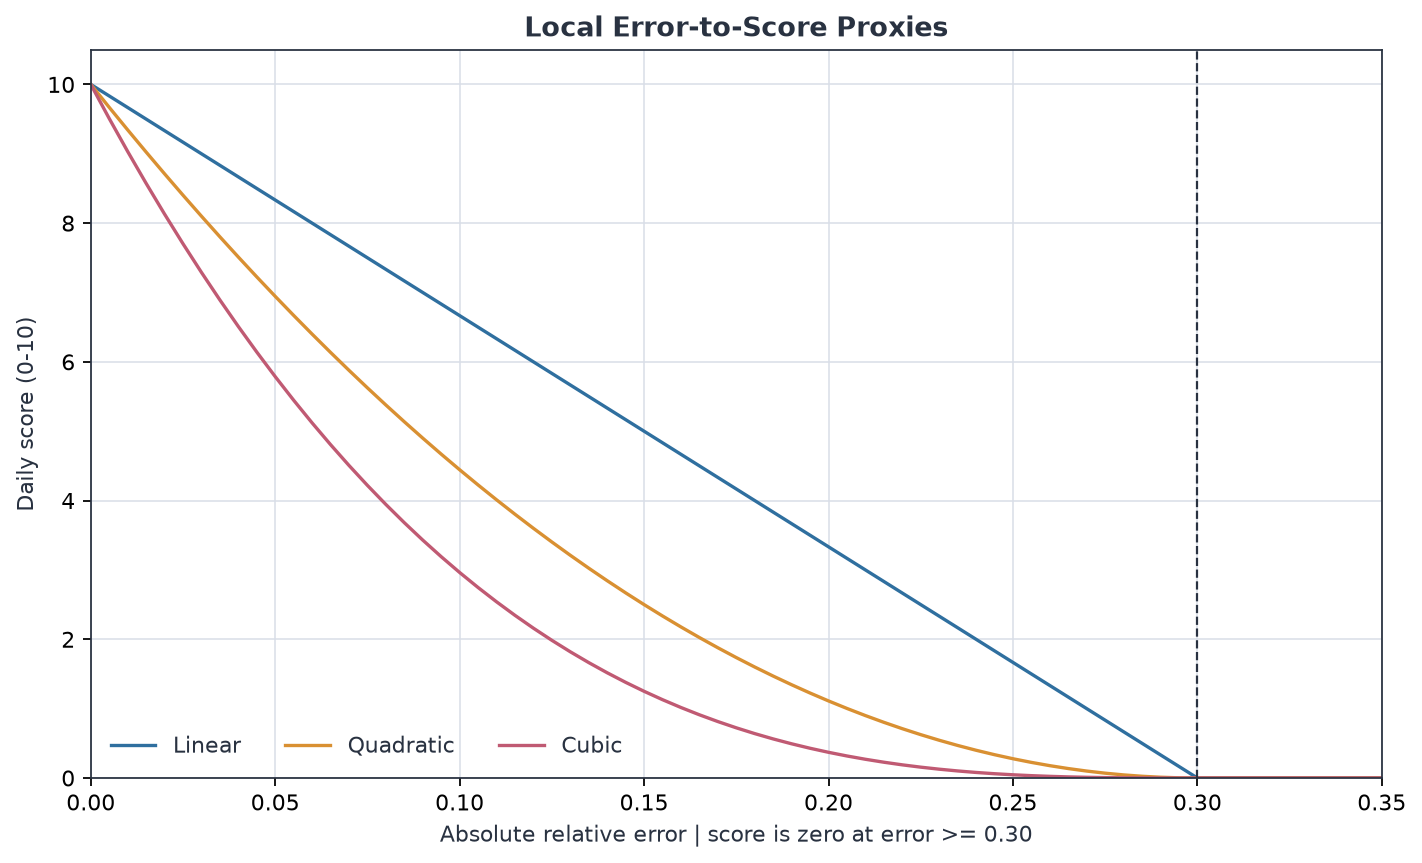

In [6]:
new_users = pd.read_csv(output_dir / 'monthly_first_seen_users.csv')
score_curves = pd.read_csv(output_dir / 'score_curves.csv')
display(new_users)
display(score_curves[score_curves['relative_error'].isin([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])])
display(Image(filename=str(output_dir / 'first_seen_user_counts.png'), width=900))
display(Image(filename=str(output_dir / 'score_curves.png'), width=900))

## Takeaways

1. Keep 2014-08 as the main near-term holdout, but select models using several 2014 rolling windows; report the median, worst window, and days with error >= 0.30.
2. Use 2013-09 as an early-growth and holiday stress test, not as an equal peer of 2014-08.
3. Use weekday and short seasonal lags as candidate features. Treat annual or month-of-year effects as unconfirmed because only one annual cycle is available.
4. Use Fold 1 for identity-holdout development and keep Fold 2 for a final check. Pair both with the temporal first-observed cohort.
5. Compare model rankings under all three score proxies; a model whose ranking changes sharply is sensitive to the unknown official curve.